# PSet 1 — Problem 2 

Optimal labor supply equilibrium with heterogeneous ability using quadrature and nonlinear solvers.

We use `hetmacro.quadrature.qnwlege` for Gauss–Legendre nodes and weights, and `hetmacro.optimize` tools where appropriate.

In [1]:
import sys
import time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Auto-detect hetmacro repo root and add to sys.path
here = Path.cwd()
repo_root = None
for p in [here] + list(here.parents):
    cand = p / 'Heterogeneity In Macroeconomics - Github'
    if cand.exists():
        repo_root = cand
        break
if repo_root is None:
    raise RuntimeError('Could not locate hetmacro repo root')
sys.path.insert(0, str(repo_root))

# Instead of using compecon, I use my own package - hetmacro
from hetmacro import quadrature as hq
from hetmacro import optimize as ho

np.set_printoptions(precision=4, suppress=True)

## 2.1 Truncated Pareto quadrature

Ability distribution: $F(e)=1-e^{-\alpha}$, truncated at $\bar e$ such that $1-F(\bar e)=10^{-12}$.

ebar = 1000.0
sum(w) = 1.0000000003868814
E[e^1] true=  1.333333 quad=  1.333333  |diff|=3.87e-10
E[e^2] true=  1.999998 quad=  1.999998  |diff|=3.88e-10
E[e^3] true=  3.996000 quad=  3.996000  |diff|=3.89e-10


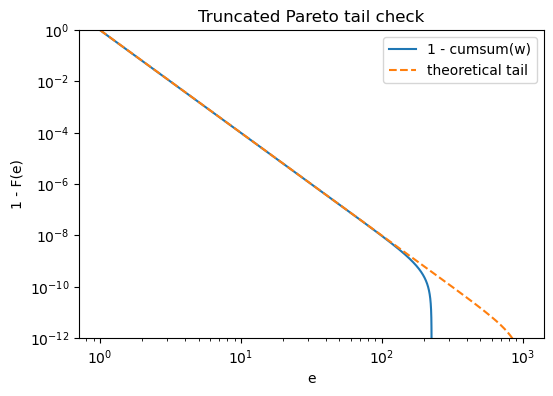

In [2]:
# Parametrization of the ability distribution
alpha = 4.0
ebar = 10.0 ** (12.0 / alpha)

# Calculate the gauss-legendre nodes and weights
n = 10000  # increase toward 10_000 once everything works
e_nodes, w_leg = hq.qnwlege(int(n), 1.0, ebar)

# truncated Pareto pdf on [1, ebar]
den = (1.0 - ebar ** (-alpha))
pdf = alpha * e_nodes ** (-(alpha + 1.0)) / den

# Multiply the pareto pdf by the gauss-legendre weights, so we approximate the integral of the pdf
w = w_leg * pdf # weights for the ability distribution

print('ebar =', ebar)
print('sum(w) =', w.sum())

def pareto_trunc_moment(k): 
    return (alpha / (alpha - k)) * (1.0 - ebar ** (k - alpha)) / (1.0 - ebar ** (-alpha))

for k in [1, 2, 3]:
    m_true = pareto_trunc_moment(k)
    m_quad = np.dot(w, e_nodes ** k)
    print(f"E[e^{k}] true={m_true:10.6f} quad={m_quad:10.6f}  |diff|={abs(m_true-m_quad):.2e}")

# tail plot: 1 - Fhat(e)
tail_emp = 1.0 - np.cumsum(w)
tail_true = (e_nodes ** (-alpha) - ebar ** (-alpha)) / (1.0 - ebar ** (-alpha))

plt.figure(figsize=(6, 4))
plt.loglog(e_nodes, tail_emp, label='1 - cumsum(w)')
plt.loglog(e_nodes, tail_true, '--', label='theoretical tail')
plt.ylim(1e-12, 1)
plt.xlabel('e')
plt.ylabel('1 - F(e)')
plt.legend()
plt.title('Truncated Pareto tail check')
plt.show()

## 2.2/2.3 Solving for equilibrium labor supply

Approach 1 (as in `start.m`): solve the full $n$-dimensional system for $h$.
1. Guess $h$ (same size as the ability grid).
2. Compute $L, W, T$ and consumption $c$ implied by $h$.
3. Evaluate the household FOC residuals $F(h)$.
4. Use Broyden to solve $F(h)=0$ directly for $h$.

**Why doesn't the FOC residual converge as tightly as in Approach 2?**  
Here every equation $F_i(h)$ depends on *all* $h$ through aggregate labor $L = \sum \omega_i e_i h_i$ (hence $W$ and $T$). The true Jacobian is *dense*. We use `solve_broyden`, which assumes a *diagonal* Jacobian (each equation depends mainly on its own $h_i$). That approximation is wrong for this coupled system, so the solver can get "close" (smooth plot, small residual in norm) but may not drive *every* component below 1e-13 within max_iter. In Approach 2, given $W$, the inner problem is *truly componentwise* (each FOC depends only on that agent's $h_i$), so the diagonal approximation fits and the residual converges to negligible.


n_broyden: 2000
sum(w_b): 1.0000000002529252
broyden iterations: 200
final max |residual|: 0.00023210203828138987
broyden success (tol=1e-13): False
broyden success (practical, <1e-10): False
Broyden time (s): 0.012
||FOC residual||_2: 0.0010029098387337155
goods market error |sum w c - Y|: 8.782330418455331e-11
T: 0.34722644230182564
L: 1.1008317719145286
Y: 1.085082632193205
W: 0.8378394055252936


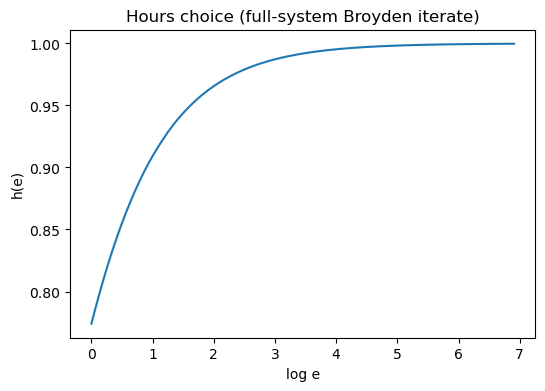

In [3]:
# --- Approach 1: full n-dimensional system F(h)=0 (trace iterations) ---
# Mirrors MATLAB: h = broyden('equilibrium', h0, p)

sigma = 1.0
gamma = 1.0
tau = 0.2
eta = 0.85

n_broyden = 2000

e_b, w_leg_b = hq.qnwlege(int(n_broyden), 1.0, ebar)
den_b = (1.0 - ebar ** (-alpha))
pdf_b = alpha * e_b ** (-(alpha + 1.0)) / den_b
w_b = w_leg_b * pdf_b

print('n_broyden:', n_broyden)
print('sum(w_b):', float(w_b.sum()))


def equilibrium_residual_h(h, e, w, tau, eta, sigma, gamma, hmax=100.0):
    """FOC residuals err_i = h_i^gamma - (1-tau) W e_i c_i^{-sigma}.

    Guardrails so the solver doesn't wander into non-finite regions:
    - bound h to [1e-12, hmax]
    - penalize c<=0 instead of producing complex / inf values
    """
    h = np.asarray(h, dtype=float)
    h = np.clip(h, 1e-12, hmax)

    L = float(np.dot(w, e * h))
    W = float(eta * (L ** (eta - 1.0)))
    T = float(L ** eta - (1.0 - tau) * W * L)

    c = T + (1.0 - tau) * W * e * h
    bad = c <= 0.0
    c_safe = np.where(bad, 1.0, c)

    err = (h ** gamma) - (1.0 - tau) * W * e * (c_safe ** (-sigma))
    err = np.where(bad, 1e6 + (-c), err)
    return err


h0 = np.ones_like(e_b)
a_h = 1e-12
b_h = 100.0

# Full-system: safeguarded componentwise Broyden (solve_broyden); do NOT use ho.broyden (SciPy wrapper) here
t0_broyden = time.perf_counter()
h_star, info = ho.solve_broyden(
    lambda h: equilibrium_residual_h(h, e_b, w_b, tau, eta, sigma, gamma),
    h0,
    a_h,
    b_h,
    args=(),
    tol=1e-13,
    max_iter=200,
    return_info=True,
)
t_broyden_s = time.perf_counter() - t0_broyden
iters = len(info['f_norm'])
f_max_final = info['f_maxabs'][-1] if info['f_maxabs'] else float('nan')
# solve_broyden only exits early when *all* components have |residual| < tol; else it runs to max_iter
# So we may hit max_iter with a few equations still slightly above 1e-13; treat as success if residual is small
ok_strict = f_max_final < 1e-13
ok = ok_strict or (f_max_final < 1e-10)  # practical convergence

print('broyden iterations:', iters)
print('final max |residual|:', f_max_final)
print('broyden success (tol=1e-13):', ok_strict)
print('broyden success (practical, <1e-10):', ok)
print('Broyden time (s):', round(t_broyden_s, 4))


# Report final iterate (even if solver did not declare success)
h_star = np.clip(h_star, 1e-12, 100.0)
F_star = equilibrium_residual_h(h_star, e_b, w_b, tau, eta, sigma, gamma)

L_star = float(np.dot(w_b, e_b * h_star))
W_star = float(eta * (L_star ** (eta - 1.0)))
T_star = float(L_star ** eta - (1.0 - tau) * W_star * L_star)
c_star = T_star + (1.0 - tau) * W_star * e_b * h_star
Y_star = float(L_star ** eta)

goods_err = abs(float(np.dot(w_b, np.maximum(c_star, 1e-12))) - Y_star)

print('||FOC residual||_2:', float(np.linalg.norm(F_star)))
print('goods market error |sum w c - Y|:', goods_err)
print('T:', T_star)
print('L:', L_star)
print('Y:', Y_star)
print('W:', W_star)

plt.figure(figsize=(6, 4))
plt.plot(np.log(e_b), h_star)
plt.xlabel('log e')
plt.ylabel('h(e)')
plt.title('Hours choice (full-system Broyden iterate)')
plt.savefig('../tex/problem2_labor_curve.pdf', bbox_inches='tight')
plt.show()

Approach 2 (as in `start.m`): fixed point in wages $W$.
1. Guess $W$.
2. Given $W$, solve household FOC for $h(e)$ (vectorized over nodes).
3. Aggregate $L=\sum_i \omega_i e_i h_i$.
4. Update $W\leftarrow \eta L^{\eta-1}$ (optionally damped) and iterate.

Below we do step 2 using **safeguarded componentwise Broyden** via `ho.solve_broyden(...)` (mirrors MATLAB `solve_broyden.m`).

   1 4.38e+00 5.0000
   2 3.47e-01 0.6178
   3 1.41e-01 0.9648
   4 1.74e-02 0.8234
   5 3.43e-03 0.8407
   6 6.38e-04 0.8373
   7 1.20e-04 0.8379
   8 2.25e-05 0.8378
   9 4.22e-06 0.8378
  10 7.92e-07 0.8378
  11 1.49e-07 0.8378
  12 2.79e-08 0.8378
  13 5.24e-09 0.8378
  14 9.82e-10 0.8378
  15 1.84e-10 0.8378
  16 3.46e-11 0.8378
  17 6.49e-12 0.8378
Wage fixed-point time (s): 0.0062

error in equilibrium conditions        = 1.04e-10
error in goods resource constraint     = 8.78e-11

lump-sum transfer                      =   0.347
labor supply                           =   1.101
output                                 =   1.085
wage                                   =   0.838



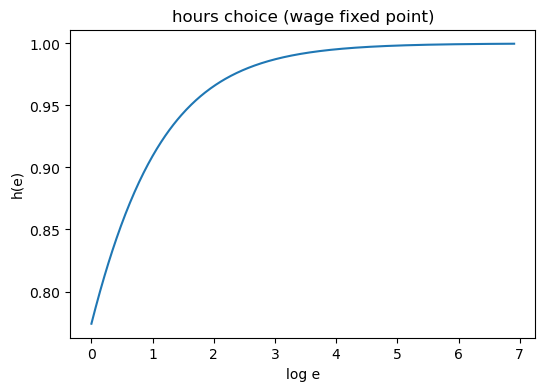

In [4]:
# --- Wage fixed point using MATLAB-style safeguarded Broyden for household FOCs ---

# Use the same quadrature nodes/weights as above (e_b, w_b)
# Bounds for hours (as in start.m)
hmin = np.zeros_like(e_b)
hmax = np.zeros_like(e_b) + 100.0


def equilibrium_from_W(W, e, w, tau, eta, sigma, gamma, h_init=None):
    """Given W, solve household FOCs for h (vectorized), then return (h, L, T)."""

    # Inner loop: solve h from FOC(h; W, T(h))=0 where T depends on aggregate L
    # We follow MATLAB's logic: for a given W we iterate once on T via L.
    # A robust alternative is to update T after solving h; here we do one consistent update.

    if h_init is None:
        h = np.ones_like(e)
    else:
        h = np.asarray(h_init, dtype=float).copy()

    # Compute L using current h to get an initial T
    L = float(np.dot(w, e * np.maximum(h, 0.0)))
    T = float(L ** eta - (1.0 - tau) * W * L)

    def laborfoc(h_vec, W_val, T_val):
        h_vec = np.asarray(h_vec, dtype=float)
        h_vec = np.maximum(h_vec, 1e-12)
        c_vec = np.maximum(T_val + (1.0 - tau) * W_val * e * h_vec, 1e-12)
        return (h_vec ** gamma) - (1.0 - tau) * W_val * e * (c_vec ** (-sigma))

    # Safeguarded componentwise Broyden (hetmacro.optimize.solve_broyden)
    h = ho.solve_broyden(
        laborfoc,
        h,
        hmin,
        hmax,
        args=(float(W), float(T)),
        tol=1e-13,
        max_iter=50
    )

    # Recompute aggregates consistently
    h = np.maximum(h, 1e-12)
    L = float(np.dot(w, e * h))
    W_implied = float(eta * (L ** (eta - 1.0)))
    T = float(L ** eta - (1.0 - tau) * W_implied * L)

    return h, L, W_implied, T


# Outer fixed point on wages (matches start.m printout style)
W = 5.0
step = 1.0

h = np.ones_like(e_b)
errW_history = []

max_iter = 50
t0_wage = time.perf_counter()

for it in range(1, max_iter):
    h, L, Wnew, T = equilibrium_from_W(W, e_b, w_b, tau, eta, sigma, gamma, h_init=h)

    errW = abs(Wnew - W)
    errW_history.append(errW)
    print(f"{it:4d} {errW:6.2e} {W:6.4f}")

    if errW < 1e-11:
        W = Wnew
        break

    W = W + step * (Wnew - W)

t_wage_s = time.perf_counter() - t0_wage
print('Wage fixed-point time (s):', round(t_wage_s, 4))

# Final objects
c = np.maximum(T + (1.0 - tau) * W * e_b * h, 1e-12)
Y = float(L ** eta)

err_foc = float(np.linalg.norm((h ** gamma) - (1.0 - tau) * W * e_b * (c ** (-sigma))))
err_goods = abs(float(np.dot(w_b, c)) - Y)

print('\nerror in equilibrium conditions        = %7.2e' % err_foc)
print('error in goods resource constraint     = %7.2e' % err_goods)
print('\nlump-sum transfer                      = %7.3f' % T)
print('labor supply                           = %7.3f' % L)
print('output                                 = %7.3f' % Y)
print('wage                                   = %7.3f\n' % W)

plt.figure(figsize=(6, 4))
plt.plot(np.log(e_b), h)
plt.title('hours choice (wage fixed point)')
plt.xlabel('log e')
plt.ylabel('h(e)')
plt.show()

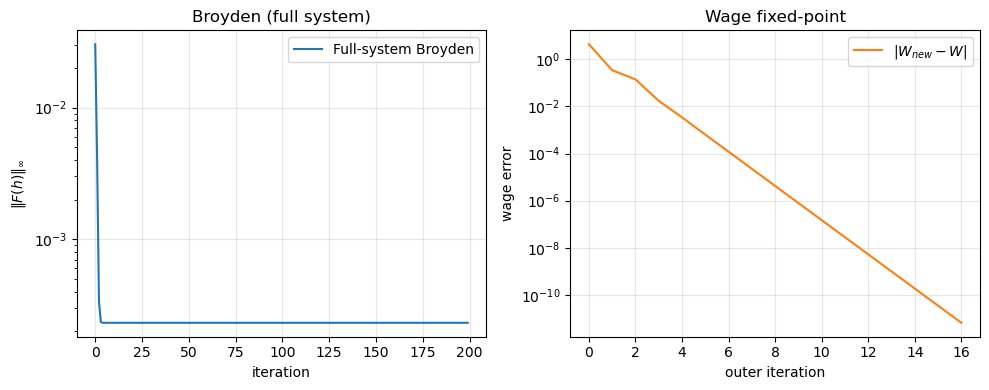

In [5]:
# Combined iteration trace: Broyden (full system) + Wage fixed-point
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.semilogy(info['f_maxabs'], label='Full-system Broyden', color='C0')
ax1.set_xlabel('iteration')
ax1.set_ylabel(r'$\|F(h)\|_\infty$')
ax1.set_title('Broyden (full system)')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax2.semilogy(errW_history, label=r'$|W_{new} - W|$', color='C1')
ax2.set_xlabel('outer iteration')
ax2.set_ylabel('wage error')
ax2.set_title('Wage fixed-point')
ax2.legend()
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../tex/figures/problem2_broyden_trace.pdf', bbox_inches='tight')
plt.show()